Best Cp Model Coefficients (k=3):
const    1.128035
X        1.906466
X2       3.024678
X3       4.078845
dtype: float64


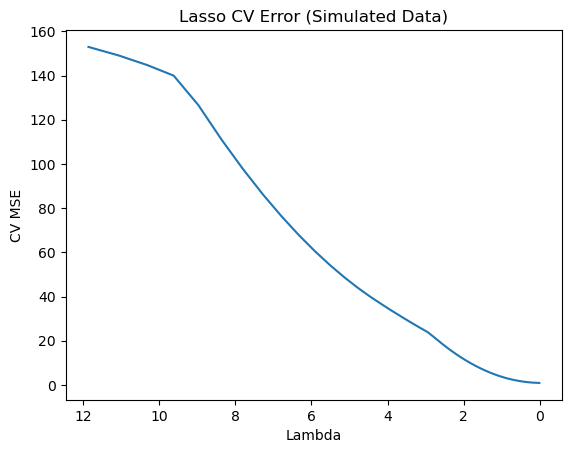

Lasso Coefficients (Simulated Data):
X       1.690317
X2      2.795793
X3     10.431095
X4      0.468986
X5      0.000000
X6      0.133609
X7      0.000000
X8      0.000000
X9      0.000000
X10     0.000000
dtype: float64
Selected Variables: ['Length', 'Diameter', 'Height', 'Whole weight', 'Whole weight.1', 'Whole weight.2', 'Shell weight', 'Sex_I', 'Sex_M']

OLS fitted with 10 predictors (incl. intercept) and 90615 rows.
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                 1.546e+04
Date:                Sun, 01 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:33:02   Log-Likelihood:            -1.9115e+05
No. Observations:               90615   AIC:                         3.823e+05
Df Residuals:        

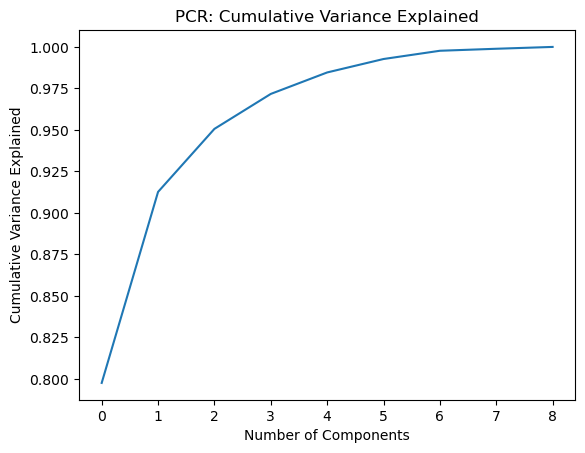

PCR components retained: 3
PCR training R^2: 0.4296186139548074
Saved submission_pcr.csv (Model 2: PCR)


In [6]:
# Assignment 3 – Nonlinear Models (Updated Full Code)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import itertools

np.random.seed(1)

# -------------------------
# Part 2: Simulated Data
# -------------------------

n = 100
X_sim = np.random.normal(size=n)
eps = np.random.normal(size=n)

beta0, beta1, beta2, beta3 = 1, 2, 3, 4
Y_sim = beta0 + beta1*X_sim + beta2*X_sim**2 + beta3*X_sim**3 + eps

df = pd.DataFrame({'X': X_sim, 'Y': Y_sim})

# Generate polynomial terms up to X^10
for i in range(2, 11):
    df[f'X{i}'] = df['X']**i

# -------------------------
# Best Subset Selection (Cp approximation)
# -------------------------

def calculate_cp(model, X_design, y):
    n_obs = len(y)
    rss = np.sum((model.predict(X_design) - y) ** 2)
    d = X_design.shape[1]  # includes intercept if present
    sigma2 = np.var(y)
    return (rss + 2 * d * sigma2) / n_obs

predictors = [f'X{i}' if i > 1 else 'X' for i in range(1, 11)]
best_models = {}

for k in range(1, 11):
    combos = list(itertools.combinations(predictors, k))
    best_cp = np.inf
    for combo in combos:
        X_temp = sm.add_constant(df[list(combo)], has_constant="add")
        model = sm.OLS(df['Y'], X_temp).fit()
        cp = calculate_cp(model, X_temp, df['Y'])
        if cp < best_cp:
            best_cp = cp
            best_models[k] = model

print("Best Cp Model Coefficients (k=3):")
print(best_models[3].params)

# -------------------------
# Lasso on Simulated Data
# -------------------------

scaler_sim = StandardScaler()
X_poly = scaler_sim.fit_transform(df[predictors])

lasso_sim = LassoCV(cv=5, random_state=1)
lasso_sim.fit(X_poly, Y_sim)

plt.plot(lasso_sim.alphas_, lasso_sim.mse_path_.mean(axis=1))
plt.xlabel("Lambda")
plt.ylabel("CV MSE")
plt.title("Lasso CV Error (Simulated Data)")
plt.gca().invert_xaxis()
plt.show()

print("Lasso Coefficients (Simulated Data):")
print(pd.Series(lasso_sim.coef_, index=predictors))

# -------------------------
# Part 3: Kaggle – Abalone Example
# -------------------------

# Load Kaggle dataset (make sure train.csv/test.csv are in your working directory)
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

# Separate target and drop ID from predictors
y = pd.to_numeric(train["Rings"], errors="raise")

X_raw = train.drop(columns=["Rings", "id"], errors="ignore")
test_raw = test.drop(columns=["id"], errors="ignore")

# One-hot encode categoricals
X = pd.get_dummies(X_raw, drop_first=True)
test_X = pd.get_dummies(test_raw, drop_first=True)

# Align test columns to train columns
test_X = test_X.reindex(columns=X.columns, fill_value=0)

# Force numeric
X = X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
test_X = test_X.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)

# Drop any rows with missing values (should be rare, but safe)
mask = ~X.isna().any(axis=1)
X = X.loc[mask]
y = y.loc[mask]

# -------------------------
# MODEL 1: Regularization (LassoCV) + OLS refit for interpretation
# -------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
test_scaled = scaler.transform(test_X)

lasso_kaggle = LassoCV(cv=5, random_state=1)
lasso_kaggle.fit(X_scaled, y)

selected = X.columns[lasso_kaggle.coef_ != 0].tolist()
print("Selected Variables:", selected)

# If Lasso selects nothing (rare), fallback to top 10 coefficients by magnitude
if len(selected) == 0:
    top_idx = np.argsort(np.abs(lasso_kaggle.coef_))[-10:]
    selected = X.columns[top_idx].tolist()
    print("Lasso selected none; fallback selected:", selected)

# ---- OLS refit (interpretation only) ----
# Bulletproof conversion to avoid dtype errors
X_sel = X.loc[:, selected].copy()
X_sel = X_sel.apply(pd.to_numeric, errors="coerce").replace([np.inf, -np.inf], np.nan)
X_sel = X_sel.dropna(axis=1, how="all")

mask2 = ~X_sel.isna().any(axis=1)
X_sel = X_sel.loc[mask2]
y_ols = y.loc[mask2]

X_selected = sm.add_constant(X_sel, has_constant="add")
ols_model = sm.OLS(y_ols.values.astype(float), X_selected.values.astype(float)).fit()

print("\nOLS fitted with", X_selected.shape[1], "predictors (incl. intercept) and", X_selected.shape[0], "rows.")
print(ols_model.summary())

# ---- Kaggle predictions for Model 1 (Lasso) ----
pred_lasso = lasso_kaggle.predict(test_scaled)

# RMSLE-safe: clip negatives to 0
pred_lasso = np.maximum(pred_lasso, 0)

submission_lasso = pd.DataFrame({
    "id": test["id"],
    "Rings": pred_lasso
})

submission_lasso.to_csv("submission.csv", index=False)
print("\nSaved submission.csv (Model 1: LassoCV)")

# -------------------------
# MODEL 2: Principal Components Regression (PCR)
# -------------------------

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCR: Cumulative Variance Explained")
plt.show()

# Keep components that explain 95% of variance
n_comp = np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1
X_reduced = X_pca[:, :n_comp]

pcr_model = LinearRegression()
pcr_model.fit(X_reduced, y)

print("PCR components retained:", n_comp)
print("PCR training R^2:", pcr_model.score(X_reduced, y))

# Transform the test set using the SAME PCA fit
test_pca = pca.transform(test_scaled)
test_reduced = test_pca[:, :n_comp]

pred_pcr = pcr_model.predict(test_reduced)

# RMSLE-safe: clip negatives to 0
pred_pcr = np.maximum(pred_pcr, 0)

submission_pcr = pd.DataFrame({
    "id": test["id"],
    "Rings": pred_pcr
})

submission_pcr.to_csv("submission_pcr.csv", index=False)
print("Saved submission_pcr.csv (Model 2: PCR)")